Part 1: Complete Workflow Function
Using device: cpu

Part 2: Running a Single Experiment

Training with lr=0.01, epochs=100
------------------------------------------------------------


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Final - Train Loss: 0.0036, Val Loss: 0.0189, Test Loss: 0.0311
Learned - weight: 0.4398 (true: 0.7), bias: 0.3607 (true: 0.3)
Model saved to: saved_models/experiment_1_lr0.01_e100.pth


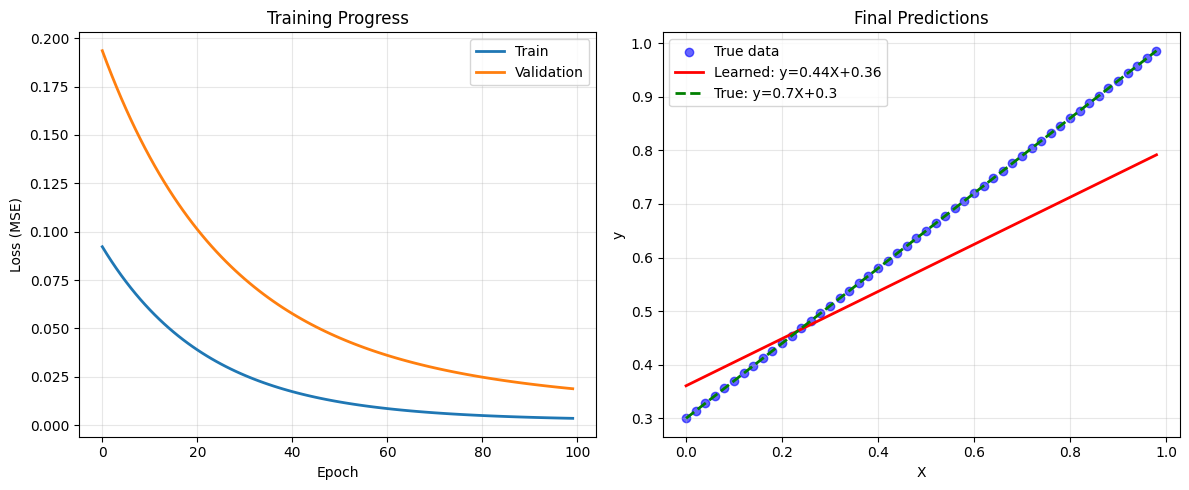


Part 3: Hyperparameter Experiments

Experiment with learning_rate=0.001

Training with lr=0.001, epochs=100
------------------------------------------------------------
Final - Train Loss: 0.0412, Val Loss: 0.1367, Test Loss: 0.1910
Learned - weight: 0.2521 (true: 0.7), bias: 0.2711 (true: 0.3)

Experiment with learning_rate=0.01

Training with lr=0.01, epochs=100
------------------------------------------------------------
Final - Train Loss: 0.0908, Val Loss: 0.4766, Test Loss: 0.8112
Learned - weight: -0.7020 (true: 0.7), bias: 0.6775 (true: 0.3)

Experiment with learning_rate=0.1

Training with lr=0.1, epochs=100
------------------------------------------------------------
Final - Train Loss: 0.0258, Val Loss: 0.1037, Test Loss: 0.1937
Learned - weight: 1.4872 (true: 0.7), bias: 0.0222 (true: 0.3)

Part 4: Comparing Experiments


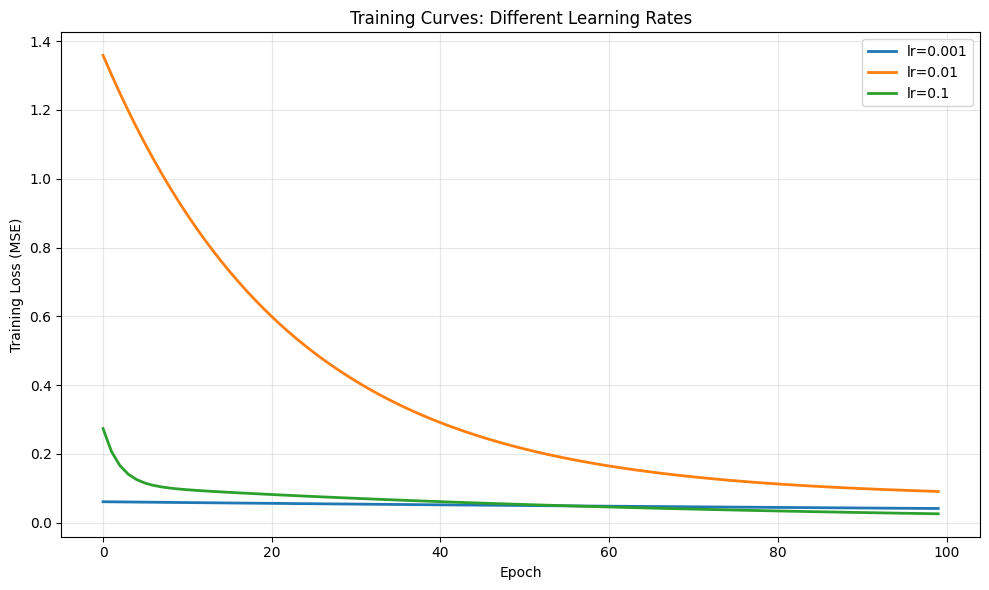


Final Results Comparison:
LR         Test Loss    Weight     Bias      
---------------------------------------------
0.001      0.1910       0.2521     0.2711    
0.010      0.8112       -0.7020    0.6775    
0.100      0.1937       1.4872     0.0222    

Part 5: Making Predictions with Loaded Models
Model loaded successfully!

Predictions for new data:
  X=0.25 -> y=0.4707
  X=0.50 -> y=0.5806
  X=0.75 -> y=0.6906

Part 6: Complete Summary

Workflow Complete!
Summary:
  - Trained 3 models with different learning rates
  - Best test loss: 0.1910
  - Models saved to: saved_models/
  - Device used: cpu

Key Takeaways:
  - Learning rate significantly affects convergence
  - Too small: slow learning
  - Too large: instability
  - Just right: fast, stable convergence

Exercises

Exercise 1: Vary number of epochs
Tip: Look for when val loss starts increasing

Exercise 2: Compare SGD vs Adam
Tip: optim.Adam(model.parameters(), lr=0.01)

Exercise 3: Add noise to data
Tip: y_noisy = y + torch

In [1]:
"""
Exercise 5: Complete PyTorch Workflow
PyTorch Workflow Fundamentals - Module 2

This exercise covers:
- Putting together the complete workflow
- Device-agnostic code
- Hyperparameter experimentation
- Training from scratch to deployment
- Comparing experiments

Learning Mottos:
- If in doubt, run the code!
- Experiment, experiment, experiment!
- Visualize, visualize, visualize!
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
from datetime import datetime

# Set random seed for reproducibility
torch.manual_seed(42)

# ============================================
# Part 1: Complete Workflow Function
# ============================================

print("=" * 60)
print("Part 1: Complete Workflow Function")
print("=" * 60)


def train_linear_regression(
    weight=0.7,
    bias=0.3,
    train_ratio=0.7,
    val_ratio=0.15,
    learning_rate=0.01,
    epochs=100,
    device='cpu',
    save_model=False,
    model_name='linear_model'
):
    """
    Complete workflow for linear regression
    """
    print(f"\nTraining with lr={learning_rate}, epochs={epochs}")
    print("-" * 60)

    # 1. Prepare data
    X = torch.arange(0, 1, 0.02).unsqueeze(dim=1).to(device)
    y = weight * X + bias

    train_split = int(train_ratio * len(X))
    val_split = int((train_ratio + val_ratio) * len(X))

    X_train, y_train = X[:train_split], y[:train_split]
    X_val, y_val = X[train_split:val_split], y[train_split:val_split]
    X_test, y_test = X[val_split:], y[val_split:]

    # 2. Build model


    class LinearRegressionModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.weight = nn.Parameter(torch.randn(1))
            self.bias = nn.Parameter(torch.randn(1))

        def forward(self, x):
            return self.weight * x + self.bias

    model = LinearRegressionModel().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    # 3. Train
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)
            val_losses.append(val_loss.item())

    # 4. Evaluate
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test)
        test_loss = criterion(test_pred, y_test).item()

    print(f"Final - Train Loss: {train_losses[-1]:.4f}, "
          f"Val Loss: {val_losses[-1]:.4f}, Test Loss: {test_loss:.4f}")
    print(f"Learned - weight: {model.weight.item():.4f} (true: {weight}), "
          f"bias: {model.bias.item():.4f} (true: {bias})")

    # 5. Save
    results = {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'test_loss': test_loss,
        'final_weight': model.weight.item(),
        'final_bias': model.bias.item()
    }

    if save_model:
        os.makedirs('saved_models', exist_ok=True)
        save_path = f'saved_models/{model_name}_lr{learning_rate}_e{epochs}.pth'
        torch.save(model.state_dict(), save_path)
        print(f"Model saved to: {save_path}")
        results['save_path'] = save_path

    return results


# TODO: Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================
# Part 2: Running a Single Experiment
# ============================================

print("\n" + "=" * 60)
print("Part 2: Running a Single Experiment")
print("=" * 60)

results = train_linear_regression(
    learning_rate=0.01,
    epochs=100,
    device=device,
    save_model=True,
    model_name='experiment_1'
)

# TODO: Visualize results
plt.figure(figsize=(12, 5))

# Training curve
plt.subplot(1, 2, 1)
plt.plot(results['train_losses'], label='Train', linewidth=2)
plt.plot(results['val_losses'], label='Validation', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Training Progress')
plt.grid(True, alpha=0.3)

# Final predictions
plt.subplot(1, 2, 2)
X = torch.arange(0, 1, 0.02).unsqueeze(dim=1).to(device)
y_true = 0.7 * X + 0.3
with torch.no_grad():
    y_pred = results['model'](X)

plt.scatter(X.cpu(), y_true.cpu(), c='b', alpha=0.6, label='True data')
plt.plot(X.cpu(), y_pred.cpu(), 'r-', linewidth=2,
         label=f"Learned: y={results['final_weight']:.2f}X+{results['final_bias']:.2f}")
plt.plot(X.cpu(), 0.7 * X.cpu() + 0.3, 'g--', linewidth=2, label='True: y=0.7X+0.3')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Final Predictions')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# Part 3: Hyperparameter Experiments
# ============================================

print("\n" + "=" * 60)
print("Part 3: Hyperparameter Experiments")
print("=" * 60)

# TODO: Experiment with different learning rates
learning_rates = [0.001, 0.01, 0.1]
all_results = {}

for lr in learning_rates:
    print(f"\n{'='*60}")
    print(f"Experiment with learning_rate={lr}")
    print(f"{'='*60}")
    results = train_linear_regression(
        learning_rate=lr,
        epochs=100,
        device=device
    )
    all_results[lr] = results

# ============================================
# Part 4: Comparing Experiments
# ============================================

print("\n" + "=" * 60)
print("Part 4: Comparing Experiments")
print("=" * 60)

# TODO: Compare training curves
plt.figure(figsize=(10, 6))
for lr, results in all_results.items():
    plt.plot(results['train_losses'], label=f'lr={lr}', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss (MSE)')
plt.legend()
plt.title('Training Curves: Different Learning Rates')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# TODO: Compare final results
print(f"\nFinal Results Comparison:")
print(f"{'LR':<10} {'Test Loss':<12} {'Weight':<10} {'Bias':<10}")
print("-" * 45)
for lr, results in all_results.items():
    print(f"{lr:<10.3f} {results['test_loss']:<12.4f} "
          f"{results['final_weight']:<10.4f} {results['final_bias']:<10.4f}")

# ============================================
# Part 5: Making Predictions with Loaded Models
# ============================================

print("\n" + "=" * 60)
print("Part 5: Making Predictions with Loaded Models")
print("=" * 60)


# TODO: Load the best model
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1))
        self.bias = nn.Parameter(torch.randn(1))

    def forward(self, x):
        return self.weight * x + self.bias


# Load
loaded_model = LinearRegressionModel().to(device)
loaded_model.load_state_dict(torch.load('saved_models/experiment_1_lr0.01_e100.pth'))
loaded_model.eval()

print("Model loaded successfully!")

# TODO: Make predictions on new data
new_data = torch.tensor([[0.25], [0.5], [0.75]]).to(device)
with torch.no_grad():
    predictions = loaded_model(new_data)

print(f"\nPredictions for new data:")
for i, x in enumerate(new_data):
    print(f"  X={x.item():.2f} -> y={predictions[i].item():.4f}")

# ============================================
# Part 6: Complete Summary
# ============================================

print("\n" + "=" * 60)
print("Part 6: Complete Summary")
print("=" * 60)

print(f"\nWorkflow Complete!")
print(f"{'='*60}")
print(f"Summary:")
print(f"  - Trained {len(all_results)} models with different learning rates")
print(f"  - Best test loss: {min(r['test_loss'] for r in all_results.values()):.4f}")
print(f"  - Models saved to: saved_models/")
print(f"  - Device used: {device}")
print(f"\nKey Takeaways:")
print(f"  - Learning rate significantly affects convergence")
print(f"  - Too small: slow learning")
print(f"  - Too large: instability")
print(f"  - Just right: fast, stable convergence")

# ============================================
# Exercises
# ============================================

print("\n" + "=" * 60)
print("Exercises")
print("=" * 60)

# Exercise 1: Epoch experiments
print("\nExercise 1: Vary number of epochs")
# TODO: Train with 50, 100, 200, 500 epochs
# TODO: Compare results
# TODO: Identify when overfitting occurs
print("Tip: Look for when val loss starts increasing")

# Exercise 2: Optimizer comparison
print("\nExercise 2: Compare SGD vs Adam")
# TODO: Train with SGD and Adam
# TODO: Compare convergence speed
# TODO: Compare final results
print("Tip: optim.Adam(model.parameters(), lr=0.01)")

# Exercise 3: Noise robustness
print("\nExercise 3: Add noise to data")
# TODO: Add Gaussian noise to training data
# TODO: Train model on noisy data
# TODO: Compare with clean data results
print("Tip: y_noisy = y + torch.randn_like(y) * 0.1")

# Exercise 4: Different data ranges
print("\nExercise 4: Different data ranges")
# TODO: Try X in range [0, 2], [0, 10]
# TODO: Try negative values
# TODO: Analyze effect on training
print("Tip: Modify torch.arange() to change range")

# Exercise 5: Complete experiments
print("\nExercise 5: Design your own experiment")
# TODO: Come up with a hypothesis
# TODO: Design experiment to test it
# TODO: Run and analyze results
# TODO: Document findings
print("Tip: What happens if you change the weight and bias?")

print("\n" + "=" * 60)
print("Exercise 5 Complete!")
print("Remember: The three mottos apply to everything!")
print("  - If in doubt, run the code!")
print("  - Experiment, experiment, experiment!")
print("  - Visualize, visualize, visualize!")
print("=" * 60)


# Exercise 1: Epoch experiments
- TODO: Train with 50, 100, 200, 500 epochs
- TODO: Compare results
- TODO: Identify when overfitting occurs


Training with 50 epochs...

Training with lr=0.01, epochs=50
------------------------------------------------------------
Final - Train Loss: 0.0391, Val Loss: 0.0458, Test Loss: 0.0490
Learned - weight: 0.6501 (true: 0.7), bias: 0.1240 (true: 0.3)

Training with 100 epochs...

Training with lr=0.01, epochs=100
------------------------------------------------------------
Final - Train Loss: 0.0193, Val Loss: 0.0813, Test Loss: 0.1507
Learned - weight: 0.0127 (true: 0.7), bias: 0.5385 (true: 0.3)

Training with 200 epochs...

Training with lr=0.01, epochs=200
------------------------------------------------------------
Final - Train Loss: 0.0179, Val Loss: 0.0720, Test Loss: 0.1349
Learned - weight: 0.0396 (true: 0.7), bias: 0.5349 (true: 0.3)

Training with 500 epochs...

Training with lr=0.01, epochs=500
------------------------------------------------------------
Final - Train Loss: 0.0092, Val Loss: 0.0375, Test Loss: 0.0699
Learned - weight: 0.2269 (true: 0.7), bias: 0.4669 (true:

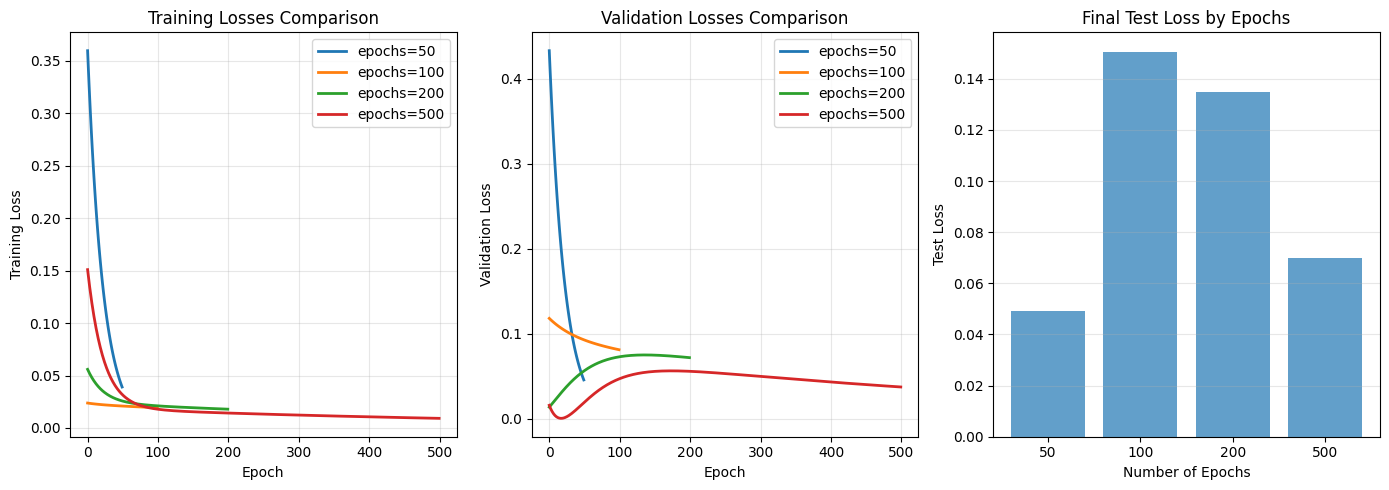


Epochs     Final Train Loss   Final Val Loss     Test Loss    Overfitting?
----------------------------------------------------------------------
50         0.0391             0.0458             0.0490       No          
100        0.0193             0.0813             0.1507       Yes         
200        0.0179             0.0720             0.1349       Yes         
500        0.0092             0.0375             0.0699       Yes         


In [5]:
epochs_list = [50, 100, 200, 500]
epoch_results = {}

for num_epochs in epochs_list:
    print(f"\nTraining with {num_epochs} epochs...")
    results = train_linear_regression(
        learning_rate=0.01,
        epochs=num_epochs,
        device=device
    )
    epoch_results[num_epochs] = results

# Compare training curves
plt.figure(figsize=(14, 5))

# Plot 1: Training losses
plt.subplot(1, 3, 1)
for epochs, results in epoch_results.items():
    plt.plot(results['train_losses'], label=f'epochs={epochs}', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Training Losses Comparison')
plt.grid(True, alpha=0.3)

# Plot 2: Validation losses
plt.subplot(1, 3, 2)
for epochs, results in epoch_results.items():
    plt.plot(results['val_losses'], label=f'epochs={epochs}', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.title('Validation Losses Comparison')
plt.grid(True, alpha=0.3)

# Plot 3: Summary comparison
plt.subplot(1, 3, 3)
test_losses = [epoch_results[e]['test_loss'] for e in epochs_list]
plt.bar(range(len(epochs_list)), test_losses, tick_label=epochs_list, alpha=0.7)
plt.xlabel('Number of Epochs')
plt.ylabel('Test Loss')
plt.title('Final Test Loss by Epochs')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Analyze overfitting
print(f"\n{'Epochs':<10} {'Final Train Loss':<18} {'Final Val Loss':<18} {'Test Loss':<12} {'Overfitting?':<12}")
print("-" * 70)
for epochs, results in epoch_results.items():
    train_loss = results['train_losses'][-1]
    val_loss = results['val_losses'][-1]
    test_loss = results['test_loss']
    overfitting = "Yes" if val_loss > train_loss * 1.2 else "No"
    print(f"{epochs:<10} {train_loss:<18.4f} {val_loss:<18.4f} {test_loss:<12.4f} {overfitting:<12}")

# Exercise 2: Optimizer comparison
- TODO: Train with SGD and Adam
- TODO: Compare convergence speed
- TODO: Compare final results


Training with SGD optimizer (lr=0.01)...
------------------------------------------------------------
Final - Train Loss: 0.0407, Val Loss: 0.1531, Test Loss: 0.2912
Learned - weight: -0.2898, bias: 0.6630

Training with Adam optimizer (lr=0.01)...
------------------------------------------------------------
Final - Train Loss: 0.0003, Val Loss: 0.0014, Test Loss: 0.0026
Learned - weight: 0.6108, bias: 0.3306


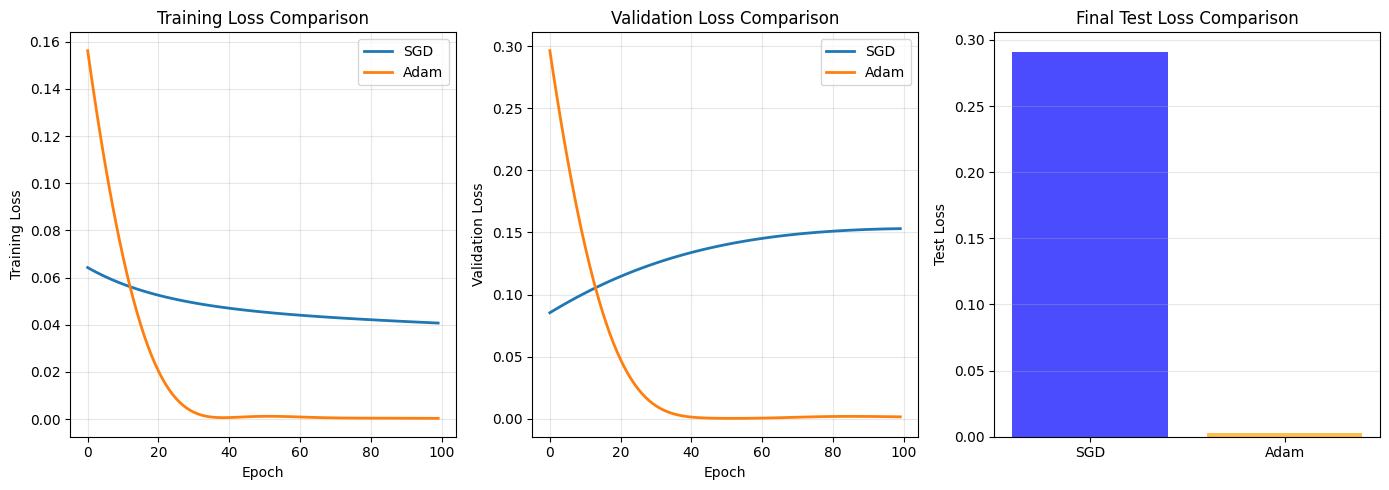


Optimizer  Final Train Loss   Final Val Loss     Test Loss    Weight     Bias      
--------------------------------------------------------------------------------
SGD        0.0407             0.1531             0.2912       -0.2898    0.6630    
Adam       0.0003             0.0014             0.0026       0.6108     0.3306    


In [4]:
optimizer_results = {}

def train_with_optimizer(optimizer_type='SGD', learning_rate=0.01, epochs=100):
    """
    Train linear regression with specified optimizer
    """
    print(f"\nTraining with {optimizer_type} optimizer (lr={learning_rate})...")
    print("-" * 60)

    # Prepare data
    X = torch.arange(0, 1, 0.02).unsqueeze(dim=1).to(device)
    y = 0.7 * X + 0.3

    train_split = int(0.7 * len(X))
    val_split = int(0.85 * len(X))

    X_train, y_train = X[:train_split], y[:train_split]
    X_val, y_val = X[train_split:val_split], y[train_split:val_split]
    X_test, y_test = X[val_split:], y[val_split:]

    # Build model
    class LinearRegressionModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.weight = nn.Parameter(torch.randn(1))
            self.bias = nn.Parameter(torch.randn(1))

        def forward(self, x):
            return self.weight * x + self.bias

    model = LinearRegressionModel().to(device)
    criterion = nn.MSELoss()
    
    # Create optimizer based on type
    if optimizer_type == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    elif optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_type}")

    # Train
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)
            val_losses.append(val_loss.item())

    # Evaluate
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test)
        test_loss = criterion(test_pred, y_test).item()

    print(f"Final - Train Loss: {train_losses[-1]:.4f}, "
        f"Val Loss: {val_losses[-1]:.4f}, Test Loss: {test_loss:.4f}")
    print(f"Learned - weight: {model.weight.item():.4f}, bias: {model.bias.item():.4f}")

    return {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'test_loss': test_loss,
        'final_weight': model.weight.item(),
        'final_bias': model.bias.item()
    }

# Train with both optimizers
sgd_results = train_with_optimizer('SGD', learning_rate=0.01, epochs=100)
adam_results = train_with_optimizer('Adam', learning_rate=0.01, epochs=100)

optimizer_results['SGD'] = sgd_results
optimizer_results['Adam'] = adam_results

# Compare convergence speed and results
plt.figure(figsize=(14, 5))

# Plot 1: Training losses
plt.subplot(1, 3, 1)
plt.plot(sgd_results['train_losses'], label='SGD', linewidth=2)
plt.plot(adam_results['train_losses'], label='Adam', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Training Loss Comparison')
plt.grid(True, alpha=0.3)

# Plot 2: Validation losses
plt.subplot(1, 3, 2)
plt.plot(sgd_results['val_losses'], label='SGD', linewidth=2)
plt.plot(adam_results['val_losses'], label='Adam', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.title('Validation Loss Comparison')
plt.grid(True, alpha=0.3)

# Plot 3: Final results comparison
plt.subplot(1, 3, 3)
optimizers = ['SGD', 'Adam']
test_losses = [sgd_results['test_loss'], adam_results['test_loss']]
plt.bar(optimizers, test_losses, alpha=0.7, color=['blue', 'orange'])
plt.ylabel('Test Loss')
plt.title('Final Test Loss Comparison')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary comparison
print(f"\n{'Optimizer':<10} {'Final Train Loss':<18} {'Final Val Loss':<18} {'Test Loss':<12} {'Weight':<10} {'Bias':<10}")
print("-" * 80)
for opt_name, results in optimizer_results.items():
    print(f"{opt_name:<10} {results['train_losses'][-1]:<18.4f} {results['val_losses'][-1]:<18.4f} "
        f"{results['test_loss']:<12.4f} {results['final_weight']:<10.4f} {results['final_bias']:<10.4f}")

# Exercise 3: Noise robustness
- TODO: Add Gaussian noise to training data
- TODO: Train model on noisy data
- TODO: Compare with clean data results


Training with noise level=0.0...
------------------------------------------------------------
Final - Train Loss: 0.0387, Val Loss: 0.0061, Test Loss: 0.0256
Learned - weight: 1.2543, bias: -0.0463

Training with noise level=0.05...
------------------------------------------------------------
Final - Train Loss: 0.0110, Val Loss: 0.0325, Test Loss: 0.0496
Learned - weight: 0.4172, bias: 0.3349

Training with noise level=0.1...
------------------------------------------------------------
Final - Train Loss: 0.0142, Val Loss: 0.0090, Test Loss: 0.0184
Learned - weight: 0.4285, bias: 0.4119

Training with noise level=0.2...
------------------------------------------------------------
Final - Train Loss: 0.1177, Val Loss: 0.0587, Test Loss: 0.1190
Learned - weight: 1.3853, bias: 0.0199


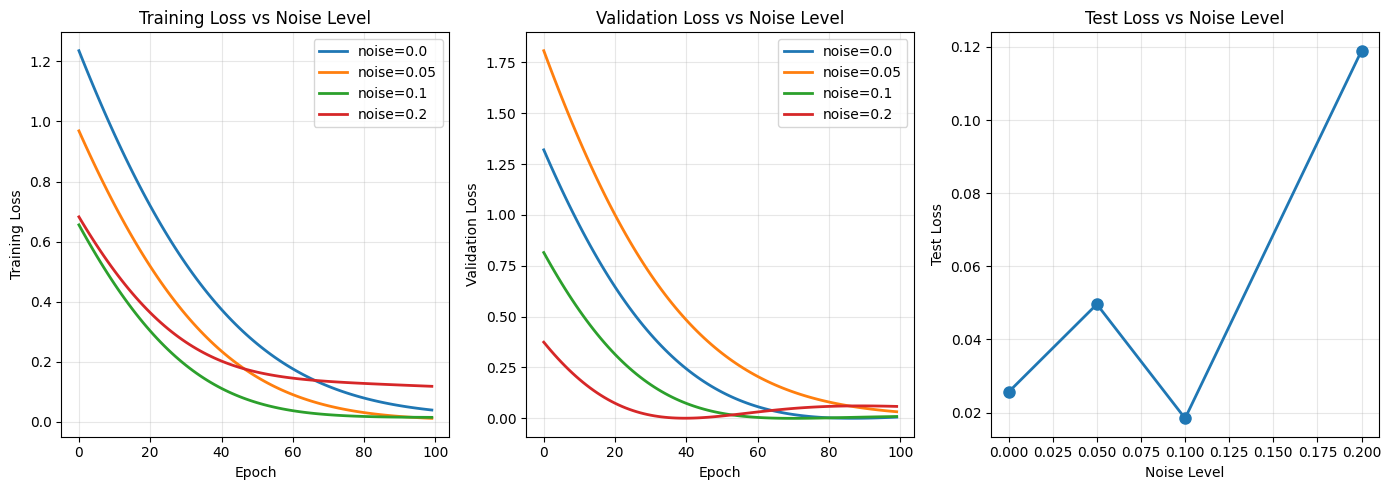


Noise Level     Final Train Loss   Final Val Loss     Test Loss    Weight Error
--------------------------------------------------------------------------------
0.00            0.0387             0.0061             0.0256       0.5543      
0.05            0.0110             0.0325             0.0496       0.2828      
0.10            0.0142             0.0090             0.0184       0.2715      
0.20            0.1177             0.0587             0.1190       0.6853      


In [7]:
noise_results = {}

def train_with_noise(noise_level=0.0, epochs=100):
    print(f"\nTraining with noise level={noise_level}...")
    print("-" * 60)

    # Prepare data
    X = torch.arange(0, 1, 0.02).unsqueeze(dim=1).to(device)
    y = 0.7 * X + 0.3
    
    # Add noise
    y_noisy = y + torch.randn_like(y) * noise_level

    train_split = int(0.7 * len(X))
    val_split = int(0.85 * len(X))

    X_train, y_train = X[:train_split], y_noisy[:train_split]
    X_val, y_val = X[train_split:val_split], y[train_split:val_split]
    X_test, y_test = X[val_split:], y[val_split:]

    # Build model
    class LinearRegressionModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.weight = nn.Parameter(torch.randn(1))
            self.bias = nn.Parameter(torch.randn(1))

        def forward(self, x):
            return self.weight * x + self.bias

    model = LinearRegressionModel().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # Train
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)
            val_losses.append(val_loss.item())

    # Evaluate
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test)
        test_loss = criterion(test_pred, y_test).item()

    print(f"Final - Train Loss: {train_losses[-1]:.4f}, "
        f"Val Loss: {val_losses[-1]:.4f}, Test Loss: {test_loss:.4f}")
    print(f"Learned - weight: {model.weight.item():.4f}, bias: {model.bias.item():.4f}")

    return {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'test_loss': test_loss,
        'final_weight': model.weight.item(),
        'final_bias': model.bias.item(),
        'noise_level': noise_level
    }

# Train with different noise levels
noise_levels = [0.0, 0.05, 0.1, 0.2]
for noise in noise_levels:
    results = train_with_noise(noise_level=noise, epochs=100)
    noise_results[noise] = results

# Compare results
plt.figure(figsize=(14, 5))

# Plot 1: Training losses for different noise levels
plt.subplot(1, 3, 1)
for noise, results in noise_results.items():
    plt.plot(results['train_losses'], label=f'noise={noise}', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Training Loss vs Noise Level')
plt.grid(True, alpha=0.3)

# Plot 2: Validation losses
plt.subplot(1, 3, 2)
for noise, results in noise_results.items():
    plt.plot(results['val_losses'], label=f'noise={noise}', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.title('Validation Loss vs Noise Level')
plt.grid(True, alpha=0.3)

# Plot 3: Final test loss vs noise level
plt.subplot(1, 3, 3)
noise_list = list(noise_results.keys())
test_losses = [noise_results[n]['test_loss'] for n in noise_list]
plt.plot(noise_list, test_losses, marker='o', linewidth=2, markersize=8)
plt.xlabel('Noise Level')
plt.ylabel('Test Loss')
plt.title('Test Loss vs Noise Level')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary comparison
print(f"\n{'Noise Level':<15} {'Final Train Loss':<18} {'Final Val Loss':<18} {'Test Loss':<12} {'Weight Error':<12}")
print("-" * 80)
for noise, results in noise_results.items():
    weight_error = abs(results['final_weight'] - 0.7)
    print(f"{noise:<15.2f} {results['train_losses'][-1]:<18.4f} {results['val_losses'][-1]:<18.4f} "
        f"{results['test_loss']:<12.4f} {weight_error:<12.4f}")

# Exercise 4: Different data ranges
- TODO: Try X in range [0, 2], [0, 10]
- TODO: Try negative values
- TODO: Analyze effect on training
print("Tip: Modify torch.arange() to change range")


Training with data range [0, 1]...
------------------------------------------------------------
Final - Train Loss: 0.0256, Val Loss: 0.1268, Test Loss: 0.2017
Learned - weight: 0.0800, bias: 0.4159

Training with data range [0, 2]...
------------------------------------------------------------
Final - Train Loss: 0.0721, Val Loss: 0.1449, Test Loss: 0.3104
Learned - weight: 0.1108, bias: 0.8178

Training with data range [0, 10]...
------------------------------------------------------------
Final - Train Loss: 1.0120, Val Loss: 5.2490, Test Loss: 8.8615
Learned - weight: 0.2429, bias: 1.4904

Training with data range [-1, 1]...
------------------------------------------------------------
Final - Train Loss: 0.0000, Val Loss: 0.0000, Test Loss: 0.0000
Learned - weight: 0.6987, bias: 0.2992

Training with data range [-5, 5]...
------------------------------------------------------------
Final - Train Loss: 9.5868, Val Loss: 20.6986, Test Loss: 43.8180
Learned - weight: -0.6822, bias: -

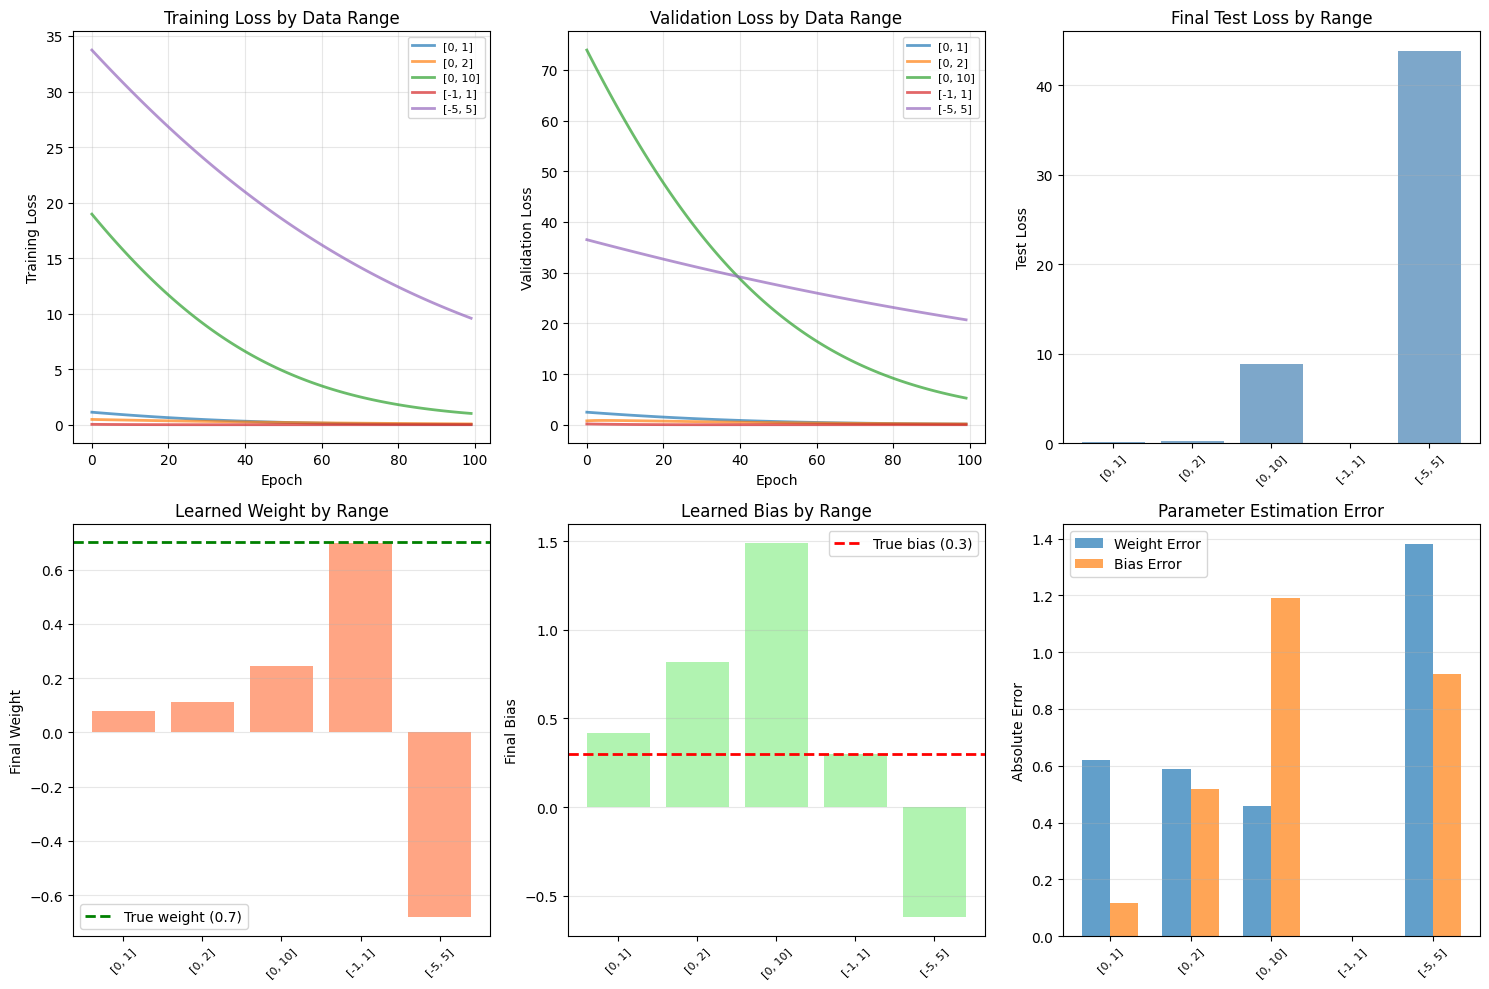


Range        Test Loss    Weight     Bias       Weight Err   Bias Err    
--------------------------------------------------------------------------------
[0, 1]       0.2017       0.0800     0.4159     0.6200       0.1159      
[0, 2]       0.3104       0.1108     0.8178     0.5892       0.5178      
[0, 10]      8.8615       0.2429     1.4904     0.4571       1.1904      
[-1, 1]      0.0000       0.6987     0.2992     0.0013       0.0008      
[-5, 5]      43.8180      -0.6822    -0.6221    1.3822       0.9221      


In [9]:
data_range_results = {}

def train_with_data_range(x_min=0, x_max=1, range_name="[0, 1]", epochs=100):
    """
    Train linear regression with different data ranges
    """
    print(f"\nTraining with data range {range_name}...")
    print("-" * 60)

    # Prepare data with specified range
    X = torch.arange(x_min, x_max, (x_max - x_min) / 50).unsqueeze(dim=1).to(device)
    y = 0.7 * X + 0.3

    train_split = int(0.7 * len(X))
    val_split = int(0.85 * len(X))

    X_train, y_train = X[:train_split], y[:train_split]
    X_val, y_val = X[train_split:val_split], y[train_split:val_split]
    X_test, y_test = X[val_split:], y[val_split:]

    # Build model
    class LinearRegressionModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.weight = nn.Parameter(torch.randn(1))
            self.bias = nn.Parameter(torch.randn(1))

        def forward(self, x):
            return self.weight * x + self.bias

    model = LinearRegressionModel().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # Train
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)
            val_losses.append(val_loss.item())

    # Evaluate
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test)
        test_loss = criterion(test_pred, y_test).item()

    print(f"Final - Train Loss: {train_losses[-1]:.4f}, "
        f"Val Loss: {val_losses[-1]:.4f}, Test Loss: {test_loss:.4f}")
    print(f"Learned - weight: {model.weight.item():.4f}, bias: {model.bias.item():.4f}")

    return {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'test_loss': test_loss,
        'final_weight': model.weight.item(),
        'final_bias': model.bias.item(),
        'X_range': (x_min, x_max),
        'range_name': range_name
    }

# Train with different data ranges
ranges = [
    (0, 1, "[0, 1]"),
    (0, 2, "[0, 2]"),
    (0, 10, "[0, 10]"),
    (-1, 1, "[-1, 1]"),
    (-5, 5, "[-5, 5]")
]

for x_min, x_max, range_name in ranges:
    results = train_with_data_range(x_min, x_max, range_name, epochs=100)
    data_range_results[range_name] = results

# Compare results
plt.figure(figsize=(15, 10))

# Plot 1: Training losses
plt.subplot(2, 3, 1)
for range_name, results in data_range_results.items():
    plt.plot(results['train_losses'], label=range_name, linewidth=2, alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend(fontsize=8)
plt.title('Training Loss by Data Range')
plt.grid(True, alpha=0.3)

# Plot 2: Validation losses
plt.subplot(2, 3, 2)
for range_name, results in data_range_results.items():
    plt.plot(results['val_losses'], label=range_name, linewidth=2, alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend(fontsize=8)
plt.title('Validation Loss by Data Range')
plt.grid(True, alpha=0.3)

# Plot 3: Test loss comparison
plt.subplot(2, 3, 3)
range_names = list(data_range_results.keys())
test_losses = [data_range_results[r]['test_loss'] for r in range_names]
plt.bar(range(len(range_names)), test_losses, alpha=0.7, color='steelblue')
plt.xticks(range(len(range_names)), range_names, rotation=45, fontsize=8)
plt.ylabel('Test Loss')
plt.title('Final Test Loss by Range')
plt.grid(True, alpha=0.3, axis='y')

# Plot 4: Weight convergence
plt.subplot(2, 3, 4)
range_names = list(data_range_results.keys())
weights = [data_range_results[r]['final_weight'] for r in range_names]
plt.bar(range(len(range_names)), weights, alpha=0.7, color='coral')
plt.axhline(y=0.7, color='g', linestyle='--', label='True weight (0.7)', linewidth=2)
plt.xticks(range(len(range_names)), range_names, rotation=45, fontsize=8)
plt.ylabel('Final Weight')
plt.title('Learned Weight by Range')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Plot 5: Bias convergence
plt.subplot(2, 3, 5)
biases = [data_range_results[r]['final_bias'] for r in range_names]
plt.bar(range(len(range_names)), biases, alpha=0.7, color='lightgreen')
plt.axhline(y=0.3, color='r', linestyle='--', label='True bias (0.3)', linewidth=2)
plt.xticks(range(len(range_names)), range_names, rotation=45, fontsize=8)
plt.ylabel('Final Bias')
plt.title('Learned Bias by Range')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Plot 6: Weight and bias errors
plt.subplot(2, 3, 6)
weight_errors = [abs(data_range_results[r]['final_weight'] - 0.7) for r in range_names]
bias_errors = [abs(data_range_results[r]['final_bias'] - 0.3) for r in range_names]
x_pos = range(len(range_names))
width = 0.35
plt.bar([p - width/2 for p in x_pos], weight_errors, width, label='Weight Error', alpha=0.7)
plt.bar([p + width/2 for p in x_pos], bias_errors, width, label='Bias Error', alpha=0.7)
plt.xticks(x_pos, range_names, rotation=45, fontsize=8)
plt.ylabel('Absolute Error')
plt.title('Parameter Estimation Error')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary comparison
print(f"\n{'Range':<12} {'Test Loss':<12} {'Weight':<10} {'Bias':<10} {'Weight Err':<12} {'Bias Err':<12}")
print("-" * 80)
for range_name, results in data_range_results.items():
    weight_err = abs(results['final_weight'] - 0.7)
    bias_err = abs(results['final_bias'] - 0.3)
    print(f"{range_name:<12} {results['test_loss']:<12.4f} {results['final_weight']:<10.4f} "
        f"{results['final_bias']:<10.4f} {weight_err:<12.4f} {bias_err:<12.4f}")

# Exercise 5: Complete experiments
- TODO: Come up with a hypothesis
- TODO: Design experiment to test it
- TODO: Run and analyze results
- TODO: Document findings
print("Tip: What happens if you change the weight and bias?")

Exercise 5: Testing Effect of True Weight and Bias

HYPOTHESIS:
Models trained on data with different true weights and biases will show
different convergence rates and final accuracy. Specifically:
- Larger weights may cause larger gradients and faster convergence
- Larger biases may shift the output but not affect the slope learning
- The optimization difficulty should be independent of the true parameters


Training with true_weight=0.3, true_bias=0.3...
------------------------------------------------------------
Final - Train Loss: 0.0101, Val Loss: 0.0386, Test Loss: 0.0730
Learned - weight: -0.1919 (true: 0.3), bias: 0.4785 (true: 0.3)

Training with true_weight=0.7, true_bias=0.3...
------------------------------------------------------------
Final - Train Loss: 0.0001, Val Loss: 0.0002, Test Loss: 0.0004
Learned - weight: 0.7410 (true: 0.7), bias: 0.2821 (true: 0.3)

Training with true_weight=1.5, true_bias=0.3...
------------------------------------------------------------
Fin

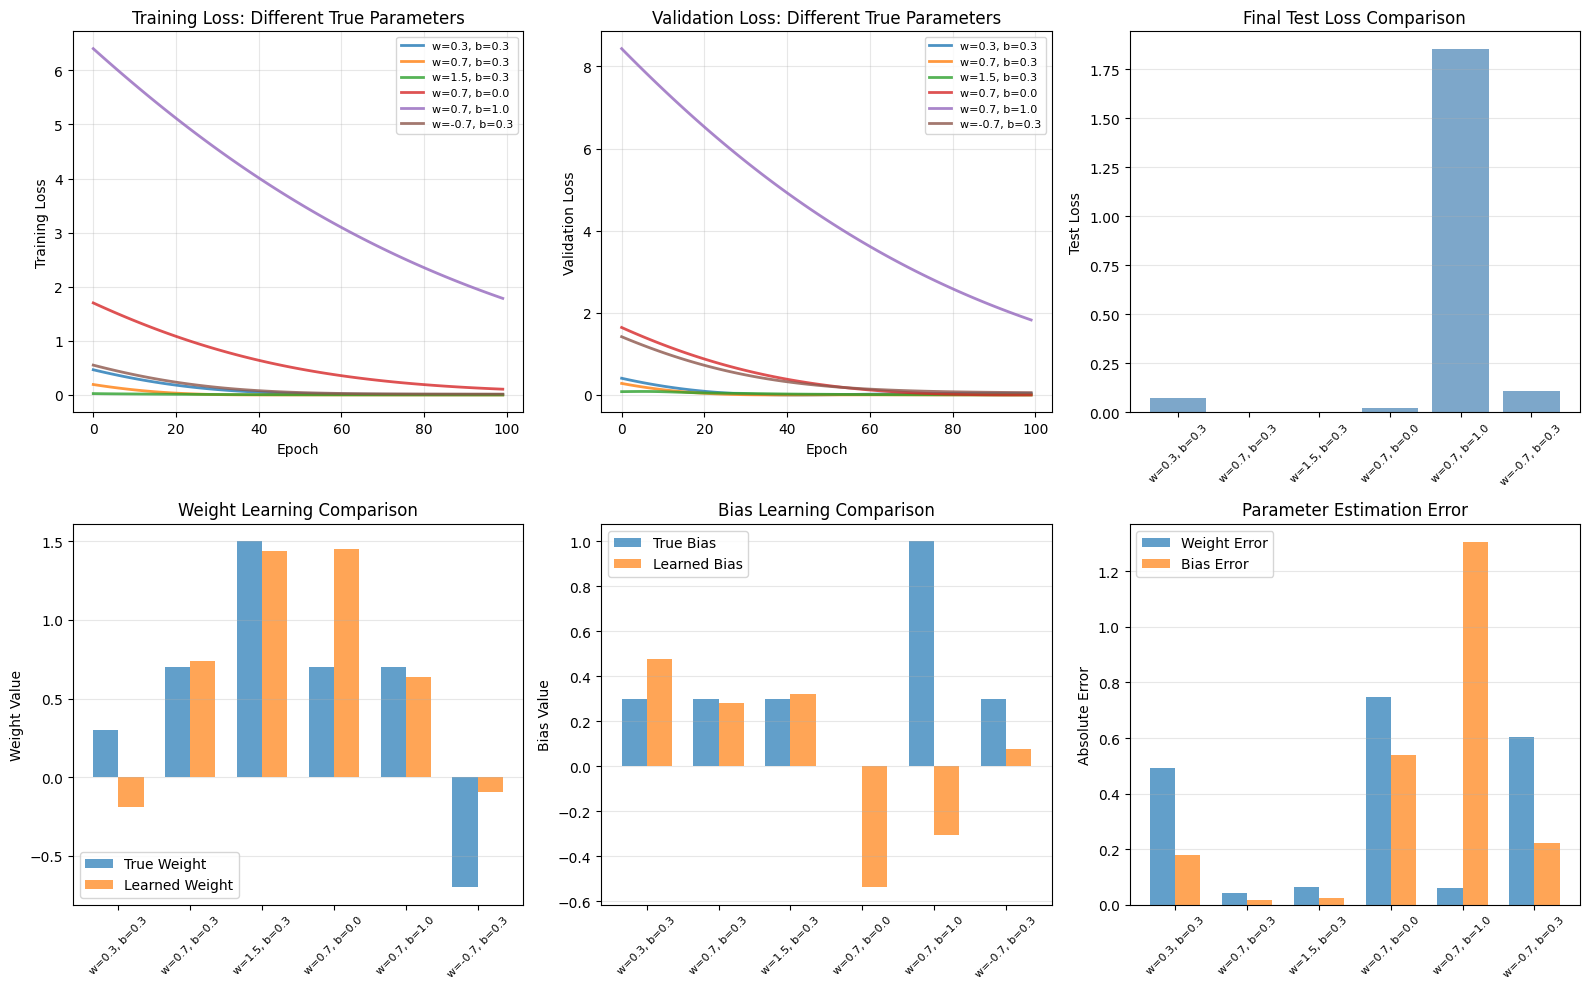


Parameters           Test Loss    Weight Err   Bias Err     Total Err   
----------------------------------------------------------------------
w=0.3, b=0.3         0.0730       0.4919       0.1785       0.6704      
w=0.7, b=0.3         0.0004       0.0410       0.0179       0.0589      
w=1.5, b=0.3         0.0014       0.0656       0.0227       0.0883      
w=0.7, b=0.0         0.0215       0.7483       0.5384       1.2867      
w=0.7, b=1.0         1.8505       0.0603       1.3055       1.3658      
w=-0.7, b=0.3        0.1084       0.6051       0.2226       0.8277      


In [ ]:
def train_with_parameters(true_weight=0.7, true_bias=0.3, epochs=100):
    """
    Train linear regression with different true weight and bias values
    """
    print(f"\nTraining with true_weight={true_weight}, true_bias={true_bias}...")
    print("-" * 60)

    # Prepare data with specified true parameters
    X = torch.arange(0, 1, 0.02).unsqueeze(dim=1).to(device)
    y = true_weight * X + true_bias

    train_split = int(0.7 * len(X))
    val_split = int(0.85 * len(X))

    X_train, y_train = X[:train_split], y[:train_split]
    X_val, y_val = X[train_split:val_split], y[train_split:val_split]
    X_test, y_test = X[val_split:], y[val_split:]

    # Build model
    class LinearRegressionModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.weight = nn.Parameter(torch.randn(1))
            self.bias = nn.Parameter(torch.randn(1))

        def forward(self, x):
            return self.weight * x + self.bias

    model = LinearRegressionModel().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # Train
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)
            val_losses.append(val_loss.item())

    # Evaluate
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test)
        test_loss = criterion(test_pred, y_test).item()

    print(f"Final - Train Loss: {train_losses[-1]:.4f}, "
        f"Val Loss: {val_losses[-1]:.4f}, Test Loss: {test_loss:.4f}")
    print(f"Learned - weight: {model.weight.item():.4f} (true: {true_weight}), "
        f"bias: {model.bias.item():.4f} (true: {true_bias})")

    return {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'test_loss': test_loss,
        'final_weight': model.weight.item(),
        'final_bias': model.bias.item(),
        'true_weight': true_weight,
        'true_bias': true_bias
    }

# Test different weight and bias combinations
parameter_results = {}

test_params = [
    (0.3, 0.3),   # Small weight
    (0.7, 0.3),   # Medium weight
    (1.5, 0.3),   # Large weight
    (0.7, 0.0),   # Zero bias
    (0.7, 1.0),   # Large bias
    (-0.7, 0.3),  # Negative weight
]

for true_w, true_b in test_params:
    key = f"w={true_w}, b={true_b}"
    results = train_with_parameters(true_weight=true_w, true_bias=true_b, epochs=100)
    parameter_results[key] = results

# Compare results
plt.figure(figsize=(16, 10))

# Plot 1: Training losses
plt.subplot(2, 3, 1)
for key, results in parameter_results.items():
    plt.plot(results['train_losses'], label=key, linewidth=2, alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend(fontsize=8)
plt.title('Training Loss: Different True Parameters')
plt.grid(True, alpha=0.3)

# Plot 2: Validation losses
plt.subplot(2, 3, 2)
for key, results in parameter_results.items():
    plt.plot(results['val_losses'], label=key, linewidth=2, alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend(fontsize=8)
plt.title('Validation Loss: Different True Parameters')
plt.grid(True, alpha=0.3)

# Plot 3: Test loss comparison
plt.subplot(2, 3, 3)
keys = list(parameter_results.keys())
test_losses = [parameter_results[k]['test_loss'] for k in keys]
plt.bar(range(len(keys)), test_losses, alpha=0.7, color='steelblue')
plt.xticks(range(len(keys)), keys, rotation=45, fontsize=8)
plt.ylabel('Test Loss')
plt.title('Final Test Loss Comparison')
plt.grid(True, alpha=0.3, axis='y')

# Plot 4: Weight learning accuracy
plt.subplot(2, 3, 4)
true_weights = [parameter_results[k]['true_weight'] for k in keys]
learned_weights = [parameter_results[k]['final_weight'] for k in keys]
x_pos = range(len(keys))
width = 0.35
plt.bar([p - width/2 for p in x_pos], true_weights, width, label='True Weight', alpha=0.7)
plt.bar([p + width/2 for p in x_pos], learned_weights, width, label='Learned Weight', alpha=0.7)
plt.xticks(x_pos, keys, rotation=45, fontsize=8)
plt.ylabel('Weight Value')
plt.title('Weight Learning Comparison')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Plot 5: Bias learning accuracy
plt.subplot(2, 3, 5)
true_biases = [parameter_results[k]['true_bias'] for k in keys]
learned_biases = [parameter_results[k]['final_bias'] for k in keys]
plt.bar([p - width/2 for p in x_pos], true_biases, width, label='True Bias', alpha=0.7)
plt.bar([p + width/2 for p in x_pos], learned_biases, width, label='Learned Bias', alpha=0.7)
plt.xticks(x_pos, keys, rotation=45, fontsize=8)
plt.ylabel('Bias Value')
plt.title('Bias Learning Comparison')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Plot 6: Parameter error analysis
plt.subplot(2, 3, 6)
weight_errors = [abs(parameter_results[k]['final_weight'] - parameter_results[k]['true_weight']) for k in keys]
bias_errors = [abs(parameter_results[k]['final_bias'] - parameter_results[k]['true_bias']) for k in keys]
plt.bar([p - width/2 for p in x_pos], weight_errors, width, label='Weight Error', alpha=0.7)
plt.bar([p + width/2 for p in x_pos], bias_errors, width, label='Bias Error', alpha=0.7)
plt.xticks(x_pos, keys, rotation=45, fontsize=8)
plt.ylabel('Absolute Error')
plt.title('Parameter Estimation Error')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Detailed summary
print(f"\n{'Parameters':<20} {'Test Loss':<12} {'Weight Err':<12} {'Bias Err':<12} {'Total Err':<12}")
print("-" * 70)
for key, results in parameter_results.items():
    w_err = abs(results['final_weight'] - results['true_weight'])
    b_err = abs(results['final_bias'] - results['true_bias'])
    total_err = w_err + b_err
    print(f"{key:<20} {results['test_loss']:<12.4f} {w_err:<12.4f} {b_err:<12.4f} {total_err:<12.4f}")